<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Loss Functions and the Hybrid Training Loop

_Prepared by Claudia Zendejas-Morales_

In supervised quantum machine learning, training begins once a variational model is assigned a clear objective function. At the single-sample level, the prediction error is quantified by a loss term; over a dataset or a mini-batch, those losses are aggregated into an empirical objective that the optimizer tries to reduce. In hybrid QML, this requires making the link between measured quantum outputs, task-specific predictions, and dataset-level objectives completely explicit.

The discussion below develops that link for common supervised settings in quantum machine learning. We study how the same measured quantum score can be interpreted differently for classification or regression, how standard losses such as binary cross-entropy, hinge loss, and mean squared error are written in a notation consistent with the rest of the QML module, and how those ingredients fit into a complete hybrid training loop. To avoid collision with the symbols $L$ and $\ell$ already used for ansatz depth and layer index, we denote per-sample supervised losses by $c$ and aggregated empirical objectives by $\mathcal{L}$.


## From measured quantum outputs to losses

For a classical sample $\vec{x}^{\,j} \in \mathbb{R}^d$, the feature map and ansatz prepare

$$
|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle = U_F(\vec{x}^{\,j})|0\rangle^{\otimes n}
$$

and

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle
=
U_A(\boldsymbol{\theta})|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle
$$

From that state, a measured feature vector can be written as

$$
\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\bigl(\langle O_1 \rangle, \dots, \langle O_R \rangle\bigr)
$$

A prediction is obtained only after a classical post-processing rule $g$ is applied:

$$
\hat y(\vec{x}^{\,j}, \boldsymbol{\theta}) = g\!\left(\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})\right)
$$

When the readout is a single scalar expectation value rather than a measured feature vector, we write

$$
s(\vec{x}^{\,j}, \boldsymbol{\theta})
=
f_O(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

so $s$ is just the scalar-readout special case of the more general measurement notation.

The per-sample loss is defined only after that prediction step:

$$
c\bigl(y^{j}, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

This distinction matters because the same quantum state can support different task semantics depending on the readout:
- a scalar expectation value can be thresholded into a class label;
- the same scalar can be transformed into a probability;
- the same scalar can be rescaled into a regression output in a bounded interval.

In other words, the circuit alone is not yet the supervised-learning objective.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/hybrid-training-loop-formal.png" alt="Formal hybrid training loop for a variational QML model" width="900"/>
</p>

This diagram makes the training objective explicit: the optimizer never updates the quantum state directly. It updates the variational parameters $\boldsymbol{\theta}$ through a classical loop built around repeated quantum evaluations.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Prediction semantics must match the loss</b><br>
A bounded expectation value such as $\langle Z_0\rangle \in [-1,1]$ is <b>not</b> automatically a probability. If we want to use <a href="https://sklearn.org/stable/modules/generated/sklearn.metrics.log_loss.html">binary cross-entropy</a>, we must first map the readout to a probability, for example with $p = (1 + \langle Z_0\rangle) / 2$ and then clip away exact 0 or 1 values numerically.
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

np.set_printoptions(precision=4, suppress=True)


## A tiny exact variational model

To make the role of the loss function easy to inspect, we use a very small two-qubit model and evaluate it with an exact statevector simulation. For a sample $\vec{x}^{\,j} = (x_1^{j}, x_2^{j})$ and trainable parameters $\boldsymbol{\theta} = (\theta_1, \theta_2)$, the feature map is

$$
U_F(\vec{x}^{\,j}) = R_y(x_1^{j}) \otimes R_y(x_2^{j})
$$

the ansatz is

$$
U_A(\boldsymbol{\theta}) = \bigl(R_y(\theta_1) \otimes R_y(\theta_2)\bigr)\operatorname{CNOT}_{0,1}
$$

and the output state can be written compactly as

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle
=
U_A(\boldsymbol{\theta})U_F(\vec{x}^{\,j})|0\rangle^{\otimes 2}
$$

The single-observable readout used in the example below is the scalar score

$$
s(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | Z_0 | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
\in [-1,1]
$$

This scalar score is not yet a label and not yet a probability. It is only a measured quantum quantity. Different losses will use it in different ways.


In [2]:
Z0_OP = SparsePauliOp.from_list([("IZ", 1.0)])

def variational_circuit(sample, weights):
    qc = QuantumCircuit(2)
    qc.ry(float(sample[0]), 0)
    qc.ry(float(sample[1]), 1)
    qc.cx(0, 1)
    qc.ry(float(weights[0]), 0)
    qc.ry(float(weights[1]), 1)
    return qc

def exact_score(sample, weights):
    state = Statevector.from_instruction(variational_circuit(sample, weights))
    return float(np.real(state.expectation_value(Z0_OP)))

def batch_scores(X, weights):
    return np.array([exact_score(sample, weights) for sample in X], dtype=float)

def probabilities_from_scores(scores, eps=1e-9):
    probs = 0.5 * (1.0 + np.asarray(scores, dtype=float))
    return np.clip(probs, eps, 1.0 - eps)

def signed_labels(y_binary):
    y_binary = np.asarray(y_binary, dtype=int)
    return 2 * y_binary - 1

def binary_cross_entropy_per_sample(y_true, probs):
    y_true = np.asarray(y_true, dtype=float)
    probs = np.asarray(probs, dtype=float)
    return -(y_true * np.log(probs) + (1.0 - y_true) * np.log(1.0 - probs))

def hinge_loss_per_sample(y_true_pm, scores):
    y_true_pm = np.asarray(y_true_pm, dtype=float)
    scores = np.asarray(scores, dtype=float)
    return np.maximum(0.0, 1.0 - y_true_pm * scores)

def mse_loss_per_sample(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return (y_true - y_pred) ** 2

def regression_head(scores, offset=0.5, scale=0.5):
    return offset + scale * np.asarray(scores, dtype=float)


## Example 1: Binary classification losses on one fixed batch

Suppose we already have a batch of four samples and a fixed parameter vector $\boldsymbol{\theta}$. The raw quantum score is

$$
s(\vec{x}^{\,j}, \boldsymbol{\theta}) = \langle Z_0 \rangle(\vec{x}^{\,j}, \boldsymbol{\theta})
$$

To use a probability-based classifier, we define

$$
p(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\frac{1 + s(\vec{x}^{\,j}, \boldsymbol{\theta})}{2}
\in [0,1]
$$

and then the threshold classifier

$$
\hat y_{\mathrm{cls}}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\mathbf{1}\!\left[p(\vec{x}^{\,j}, \boldsymbol{\theta}) \ge \frac{1}{2}\right]
$$

On a labeled dataset $\{(\vec{x}^{\,j}, y^j)\}_{j=1}^{M}$ with $y^j \in \{0,1\}$, the binary cross-entropy loss is

$$
c_{\mathrm{BCE}}\bigl(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
= - y^j \log p(\vec{x}^{\,j}, \boldsymbol{\theta}) - (1-y^j)\log\bigl(1-p(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

and the corresponding empirical risk is

$$
\mathcal{L}_{\mathrm{BCE}}(\boldsymbol{\theta})
=
\frac{1}{M}
\sum_{j=1}^{M}
c_{\mathrm{BCE}}\bigl(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

If instead we use labels $\tilde y^j \in \{-1,+1\}$ and interpret the score as a margin, the hinge loss is

$$
c_{\mathrm{hinge}}\bigl(\tilde y^j, s(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
=
\max\bigl(0, 1 - \tilde y^j s(\vec{x}^{\,j}, \boldsymbol{\theta}) \bigr)
$$

with empirical risk

$$
\mathcal{L}_{\mathrm{hinge}}(\boldsymbol{\theta})
=
\frac{1}{M}
\sum_{j=1}^{M}
c_{\mathrm{hinge}}\bigl(\tilde y^j, s(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

These losses do not punish mistakes in exactly the same way:
- cross-entropy is sensitive to how confidently wrong the predicted probability is;
- hinge loss focuses on the signed margin and becomes zero only when the margin is at least one.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Per-sample loss versus empirical risk</b><br>
In machine learning practice, the word <b>loss</b> is often used for both the per-sample quantity and the aggregated training objective. Here we keep them separate on purpose. The term $c_{\mathrm{BCE}}(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta}))$ measures the prediction error for <b>one</b> labeled sample, while $\mathcal{L}_{\mathrm{BCE}}(\boldsymbol{\theta})$ is the empirical risk obtained by averaging that quantity over the dataset or batch. In that broader sense, $\mathcal{L}$ is indeed the training loss minimized by the optimizer, but it is built from per-sample loss terms $c$.
</div>


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why there are two versions of each function</b><br>
The subscripts indicate <b>which learning criterion has been chosen</b>. The functions $c_{\mathrm{BCE}}$ and $c_{\mathrm{hinge}}$ are two different per-sample losses because they evaluate prediction error in different ways: binary cross-entropy treats the output as a probability, while hinge loss treats it as a signed margin. Their aggregated counterparts $\mathcal{L}_{\mathrm{BCE}}$ and $\mathcal{L}_{\mathrm{hinge}}$ are obtained by averaging those respective per-sample losses over data. So there are not two unrelated objective families here; there is one notation pattern, instantiated for two different supervised choices.
</div>


In [3]:
# Input samples in the supervised batch
samples_cls = np.array([
    [0.10, 0.25],
    [0.55, 0.90],
    [1.00, 0.20],
    [1.30, 1.10],
])
# Corresponding labels for the same batch
y_cls = np.array([0, 1, 1, 0])
weights_cls = np.array([0.40, -0.75])

scores_cls = batch_scores(samples_cls, weights_cls)
probs_cls = probabilities_from_scores(scores_cls)
y_cls_pm = signed_labels(y_cls)

bce_each = binary_cross_entropy_per_sample(y_cls, probs_cls)
hinge_each = hinge_loss_per_sample(y_cls_pm, scores_cls)

print("scores:", np.round(scores_cls, 4))
print("probabilities:", np.round(probs_cls, 4))
print("bce per sample:", np.round(bce_each, 4))
print("hinge per sample:", np.round(hinge_each, 4))
print("mean BCE:", float(np.mean(bce_each)))
print("mean hinge:", float(np.mean(hinge_each)))


scores: [ 0.9068  0.6258  0.4326 -0.088 ]
probabilities: [0.9534 0.8129 0.7163 0.456 ]
bce per sample: [3.0666 0.2072 0.3337 0.6088]
hinge per sample: [1.9068 0.3742 0.5674 0.912 ]
mean BCE: 1.0540572700296102
mean hinge: 0.9401206277025516


The printed values already show how the two losses respond to the same batch. Here the parameter vector is fixed by hand rather than trained, so the point is not to obtain a good classifier but to inspect how the loss functions react. The first sample is the clearest case: its label is $y^1 = 0$, but the circuit produces $s \approx 0.9068$ and therefore $p \approx 0.9534$. That is a strongly wrong probability assignment for class $0$, so the binary cross-entropy term becomes large, $c_{\mathrm{BCE}} \approx 3.0666$. The hinge term is also large, $c_{\mathrm{hinge}} \approx 1.9068$, because the signed margin is wrong as well.

By contrast, the second and third samples have positive labels and positive scores, so both losses are much smaller. The fourth sample, with label $y^4 = 0$, is classified on the correct side because its score is slightly negative, $s \approx -0.0880$, but the margin is weak and the probability $p \approx 0.4560$ is still close to $1/2$. This is why its losses remain nonzero rather than vanishing. The batch averages, $\mathcal{L}_{\mathrm{BCE}} \approx 1.0541$ and $\mathcal{L}_{\mathrm{hinge}} \approx 0.9401$, summarize these four contributions into two different training objectives built from the same raw quantum readout.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/one-score-multiple-losses.png" alt="One measured quantum score can induce different supervised objectives" width="750"/>
</p>

The same measured score can feed a probability-based classifier, a margin-based classifier, or a regression head, where <i>head</i> refers to the final classical output map applied to the quantum readout. This is why the meaning of the output must be specified before choosing the loss.


A useful qualitative reading of the output is:
- if a sample has the wrong sign and also a confident probability, cross-entropy becomes large quickly;
- hinge loss reacts to whether the signed score clears a margin threshold, not to whether the probability is calibrated;
- two losses can rank models differently even on the same batch.

For this reason, the loss must be chosen according to the meaning we assign to the output. A probability-based model is naturally trained with cross-entropy. A margin-based classifier can be discussed with hinge loss. The circuit may be the same, but the learning problem is not.


<b>Implementation note.</b> In <a href="https://qiskit-community.github.io/qiskit-machine-learning/apidocs/qiskit_machine_learning.utils.loss_functions.html">Qiskit Machine Learning's loss-function API</a>, the probability-based counterpart closest to the binary cross-entropy discussion above is <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.CrossEntropyLoss.html"><code>CrossEntropyLoss</code></a>. In classifier APIs such as <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkClassifier.html"><code>NeuralNetworkClassifier</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html"><code>VQC</code></a>, this choice is also exposed through the string <code>loss="cross_entropy"</code>. The current Qiskit Machine Learning loss-function API does not expose a dedicated hinge-loss class. PennyLane likewise does not currently expose a dedicated supervised-loss API for binary cross-entropy or hinge loss in core; instead, the usual workflow is to define the loss in the chosen interface and differentiate through the QNode, as described in <a href="https://docs.pennylane.ai/en/stable/introduction/interfaces.html">Gradients and training</a> and in the <a href="https://docs.pennylane.ai/en/stable/introduction/interfaces/torch.html">PyTorch interface guide</a>.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>What is a batch?</b><br>
A <b>batch</b> is simply a collection of several training samples processed together before computing an aggregated objective such as $\mathcal{L}_{\mathrm{BCE}}$ or $\mathcal{L}_{\mathrm{hinge}}$. In this example, the batch contains four labeled samples, so the empirical risk is obtained by averaging the corresponding four per-sample losses. When the batch contains the whole training set, one speaks of <b>full-batch</b> training; when it contains only a subset, one speaks of <b>mini-batch</b> training.
</div>


### Task 1 (coding): When do BCE and hinge prefer different parameter vectors?

Reuse the same helper functions, but now keep the batch fixed and compare the two candidate parameter vectors below:

```python
samples_task = np.array([
    [0.20, 0.10],
    [0.45, 0.80],
    [0.95, 0.35],
    [1.10, 1.05],
    [1.40, 0.55],
])
y_task = np.array([0, 1, 1, 0, 1])
weights_A = np.array([1.00, -0.70])
weights_B = np.array([-0.35, 0.20])
```

Compute the raw scores, probabilities, per-sample BCE, and per-sample hinge loss for both candidates. Then compute the corresponding batch means, decide which candidate is preferred by BCE and which is preferred by hinge, and identify the sample index whose contribution changes the most between candidates for each objective. Finally, explain in 4 to 6 sentences why the two objectives can prefer different parameter vectors even on the same batch.

Do not rewrite the model from scratch. Reuse the exact helper functions defined in the notebook.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="01-loss-functions-and-the-hybrid-training-loop-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [4]:
# Task 1 starter
samples_task = np.array([
    [0.20, 0.10],
    [0.45, 0.80],
    [0.95, 0.35],
    [1.10, 1.05],
    [1.40, 0.55],
])
y_task = np.array([0, 1, 1, 0, 1])
weights_A = np.array([1.00, -0.70])
weights_B = np.array([-0.35, 0.20])
y_task_pm = signed_labels(y_task)

def summarize_candidate(weights):
    # TODO: compute scores, probabilities, per-sample BCE, and per-sample hinge loss
    # TODO: return them in a dictionary together with mean BCE and mean hinge
    pass

# TODO:
# 1. build one summary for candidate A and one for candidate B
# 2. decide which candidate is preferred by BCE and which by hinge
# 3. identify the sample whose BCE changes the most between the two candidates
# 4. identify the sample whose hinge loss changes the most between the two candidates
# 5. explain why the two criteria can disagree on the same fixed batch


## Regression loss uses the same circuit with a different output meaning

The same measured score, that is, the same scalar readout, can be used for regression if we decide that the final prediction should be a bounded real number instead of a class probability. A simple affine regression head is

$$
\hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
a + b\, s(\vec{x}^{\,j}, \boldsymbol{\theta})
$$

where $a$ and $b$ are chosen so that the output lands in an interval appropriate for the target. If we want predictions in $[0,1]$, one common simple choice is

$$
\hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\frac{1 + s(\vec{x}^{\,j}, \boldsymbol{\theta})}{2}
$$

For targets $y^j \in \mathbb{R}$, the per-sample mean squared error is

$$
c_{\mathrm{MSE}}\bigl(y^j, \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
=
\left(y^j - \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\right)^2
$$

and the empirical risk is

$$
\mathcal{L}_{\mathrm{MSE}}(\boldsymbol{\theta})
=
\frac{1}{M}
\sum_{j=1}^{M}
c_{\mathrm{MSE}}\bigl(y^j, \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Again, the key idea is that the quantum circuit produces a score, while the task meaning is imposed by the classical post-processing and the loss.


In [5]:
samples_reg = np.array([
    [0.15, 0.20],
    [0.60, 0.75],
    [0.90, 0.40],
    [1.25, 0.95],
])
y_reg = np.array([0.10, 0.85, 0.65, 0.20])
weights_reg = np.array([0.55, -0.30])

scores_reg = batch_scores(samples_reg, weights_reg)
preds_reg = regression_head(scores_reg, offset=0.5, scale=0.5)
mse_each = mse_loss_per_sample(y_reg, preds_reg)

print("scores:", np.round(scores_reg, 4))
print("regression predictions:", np.round(preds_reg, 4))
print("MSE per sample:", np.round(mse_each, 4))
print("mean MSE:", float(np.mean(mse_each)))


scores: [ 0.8274  0.5024  0.3705 -0.1347]
regression predictions: [0.9137 0.7512 0.6852 0.4327]
MSE per sample: [0.6621 0.0098 0.0012 0.0541]
mean MSE: 0.18181789722713604


The printed values should now be read as a regression pipeline built on top of the same quantum score. The line labeled `scores:` displays the scalar readout returned by the circuit for each sample, while the line labeled `regression predictions:` shows the classical post-processing step that maps those scores into target-space values in $[0,1]$.

The per-sample MSE values show how far each prediction is from its target after squaring the difference. Here the first sample contributes the most to the average error, because its prediction $\hat y_{\mathrm{reg}} \approx 0.9137$ is far from the target $y^1 = 0.10$. By contrast, the second and third samples are fitted much better, so their squared errors are small. The final number, `mean MSE`, is the empirical objective $\mathcal{L}_{\mathrm{MSE}}$ for this batch.


In this example the circuit has not changed at all. What changed is:
- the post-processing rule, which now interprets the score as a bounded real-valued output;
- the target type, which is now a real number rather than a class label;
- the loss, which is now a squared error rather than a classification loss.

This is one reason why it is helpful to separate the notation into state, measured features, prediction, and loss. It keeps the learning objective explicit.


<b>Implementation note.</b> For squared-error training, Qiskit Machine Learning provides <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.L2Loss.html"><code>L2Loss</code></a>, and regressor APIs such as <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkRegressor.html"><code>NeuralNetworkRegressor</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQR.html"><code>VQR</code></a> expose it through <code>loss="squared_error"</code>. PennyLane does not currently provide a dedicated core API for supervised MSE; its deprecated <a href="https://docs.pennylane.ai/en/stable/development/deprecations.html"><code>qml.qnn.cost.SquaredErrorLoss</code></a> has been removed, so the standard PennyLane workflow is now to define the regression loss explicitly or to rely on the native loss functions of the selected interface.


### Task 2 (coding): Fit an affine regression head to fixed quantum scores

Work with the batch below:

```python
samples_task = np.array([
    [0.12, 0.18],
    [0.52, 0.68],
    [0.98, 0.42],
    [1.28, 0.88],
    [1.45, 0.60],
])
y_task = np.array([0.08, 0.76, 0.62, 0.18, 0.48])
weights_task = np.array([0.35, -0.25])
```

Compute the quantum scores only once and then treat them as a one-dimensional classical feature. Using those fixed scores, fit the affine head $\hat y = a + b s$ that minimizes the mean squared error on this batch. Compare its predictions and mean MSE against the default bounded head with `offset=0.50` and `scale=0.50`, and report the fitted values of $a$ and $b$. Finally, determine whether the fitted slope is positive, negative, or close to zero, and use that result to assess how informative these particular quantum scores are for this regression target.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="01-loss-functions-and-the-hybrid-training-loop-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [6]:
# Task 2 starter
samples_task = np.array([
    [0.12, 0.18],
    [0.52, 0.68],
    [0.98, 0.42],
    [1.28, 0.88],
    [1.45, 0.60],
])
y_task = np.array([0.08, 0.76, 0.62, 0.18, 0.48])
weights_task = np.array([0.35, -0.25])

# TODO:
# 1. compute the shared quantum scores once
# 2. build the design matrix for an affine head y_hat = a + b s
# 3. fit a and b with np.linalg.lstsq or an equivalent least-squares routine
# 4. compute predictions and mean MSE for the fitted head
# 5. compare against the default bounded head offset=0.50, scale=0.50
# 6. inspect the fitted slope and decide what it says about the usefulness of the scores


## From per-sample loss to empirical risk

The abstract supervised-learning objective is

$$
\mathcal{L}(\boldsymbol{\theta})
=
\frac{1}{M}
\sum_{j=1}^{M}
c\bigl(y^{j}, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

In this notation, $c$ denotes the supervised loss attached to one sample, while $\mathcal{L}$ denotes the empirical training objective obtained after aggregating those losses over data.

For hybrid QML, computing this objective requires repeated classical-quantum interaction:
1. encode each sample with the feature map $U_F(\vec{x}^{\,j})$;
2. execute the variational circuit $U_A(\boldsymbol{\theta})$;
3. measure the chosen observable(s) to obtain either a scalar score or a feature vector $\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})$;
4. apply the classical post-processing rule that defines $\hat y(\vec{x}^{\,j}, \boldsymbol{\theta})$;
5. aggregate the losses across the batch.

In practice, one often works with a mini-batch $B \subset \{1,\dots,M\}$ and optimizes

$$
\mathcal{L}_B(\boldsymbol{\theta})
=
\frac{1}{|B|}
\sum_{j \in B}
c\bigl(y^{j}, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Thus, full-batch and mini-batch training differ in the set over which the empirical risk is approximated at each update step, not in the conceptual definition of the model.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Scope note</b><br>
To keep the loop mechanics visible, the next example uses an intentionally simple coordinate-search update rule. It is a didactic optimizer, not a recommendation. The next notebook studies gradients and standard optimizers in a more systematic way.
</div>


In [7]:
X, y = make_moons(n_samples=120, noise=0.18, random_state=21)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=21, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=21, stratify=y_train_val
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("train size:", len(X_train))
print("validation size:", len(X_val))
print("test size:", len(X_test))


train size: 72
validation size: 24
test size: 24


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/full-batch-vs-mini-batch.png" alt="Comparison between full-batch and mini-batch training updates" width="800"/>
</p>

Both update styles aim at the same empirical-risk objective, but they estimate it with different subsets of the training data at each step.


In [8]:
def mean_binary_cross_entropy(X_batch, y_batch, weights):
    scores = batch_scores(X_batch, weights)
    probs = probabilities_from_scores(scores)
    return float(np.mean(binary_cross_entropy_per_sample(y_batch, probs)))

def predict_probabilities(X_batch, weights):
    return probabilities_from_scores(batch_scores(X_batch, weights))

def predict_labels(X_batch, weights, threshold=0.5):
    probs = predict_probabilities(X_batch, weights)
    return (probs >= threshold).astype(int)

def iterate_batches(X_data, y_data, batch_size, rng):
    if batch_size is None or batch_size >= len(X_data):
        yield X_data, y_data
        return

    order = rng.permutation(len(X_data))
    for start in range(0, len(order), batch_size):
        batch_ids = order[start:start + batch_size]
        yield X_data[batch_ids], y_data[batch_ids]

def coordinate_search_step(weights, X_batch, y_batch, step_size):
    current_loss = mean_binary_cross_entropy(X_batch, y_batch, weights)
    best_weights = weights.copy()
    best_loss = current_loss

    for idx in range(len(weights)):
        for direction in (+1.0, -1.0):
            trial = weights.copy()
            trial[idx] += direction * step_size
            trial_loss = mean_binary_cross_entropy(X_batch, y_batch, trial)
            if trial_loss < best_loss:
                best_weights = trial
                best_loss = trial_loss

    return best_weights, best_loss

def train_coordinate_search(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights,
    epochs=30,
    batch_size=24,
    initial_step_size=0.35,
    seed=7,
):
    rng = np.random.default_rng(seed)
    weights = np.array(initial_weights, dtype=float)
    history = {
        "train_loss": [],
        "val_loss": [],
        "step_size": [],
    }

    for epoch in range(epochs):
        step_size = initial_step_size / np.sqrt(epoch + 1.0)

        for X_batch, y_batch in iterate_batches(X_train, y_train, batch_size, rng):
            weights, _ = coordinate_search_step(weights, X_batch, y_batch, step_size)

        history["train_loss"].append(mean_binary_cross_entropy(X_train, y_train, weights))
        history["val_loss"].append(mean_binary_cross_entropy(X_val, y_val, weights))
        history["step_size"].append(step_size)

    return weights, history


initial weights: [ 0.2 -0.2]
trained weights: [ 2.0267 -0.4592]
final train loss: 0.811
final validation loss: 1.0682
test BCE: 0.8424
test accuracy: 0.5


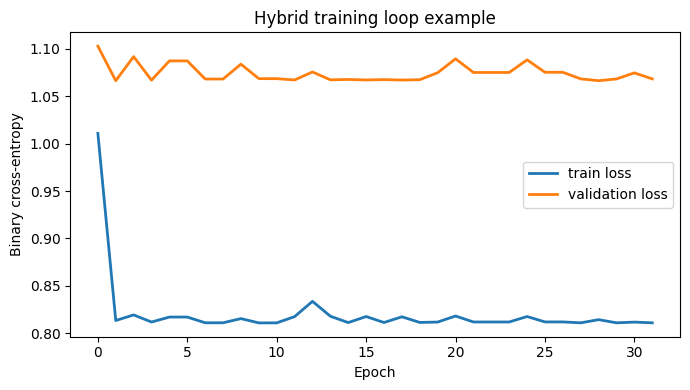

In [9]:
initial_weights = np.array([0.20, -0.20])

trained_weights, history = train_coordinate_search(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights=initial_weights,
    epochs=32,
    batch_size=24,
    initial_step_size=0.40,
    seed=7,
)

y_test_pred = predict_labels(X_test, trained_weights, threshold=0.5)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_bce = mean_binary_cross_entropy(X_test, y_test, trained_weights)

print("initial weights:", initial_weights)
print("trained weights:", np.round(trained_weights, 4))
print("final train loss:", round(history["train_loss"][-1], 4))
print("final validation loss:", round(history["val_loss"][-1], 4))
print("test BCE:", round(test_bce, 4))
print("test accuracy:", round(test_accuracy, 4))

plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train loss", linewidth=2)
plt.plot(history["val_loss"], label="validation loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Hybrid training loop example")
plt.legend()
plt.tight_layout()
plt.show()


The printed values and the plot should be read together. The change from `initial weights` to `trained weights` shows that the optimizer did update the variational parameters, and the drop in training BCE confirms that the optimization loop is doing nontrivial work. So yes, there is genuine optimization here.

At the same time, the example is intentionally modest: this is a very small two-parameter variational model trained with a deliberately simple coordinate-search update on a noisy `make_moons` dataset. The plot shows that the training loss drops quickly and then stabilizes, while the validation loss stays noticeably higher. That gap indicates that the learned parameters are not transferring well to unseen validation data. The test accuracy of `0.5` therefore does not contradict the optimization step: it means that, after thresholding the predicted probabilities at `0.5`, the model still fails to separate the two classes well on the test split. In other words, the objective improved, but the resulting classifier remains weak. The point of this example is to make the structure of a hybrid training loop concrete and to show why one must inspect train, validation, and test behavior together rather than assuming that a lower loss automatically means a strong classifier.


The loop above is hybrid in the precise sense used throughout this course:
1. a classical batch is selected;
2. each sample is encoded into a quantum circuit;
3. the circuit is evaluated to obtain measured scores;
4. those scores are transformed into probabilities;
5. a classical loss is aggregated over the batch;
6. a classical update rule proposes new variational parameters.

Even though the coordinate-search update is deliberately simple, the pipeline structure is already the same as in more advanced optimizers. The quantum subroutine provides model evaluations, while the optimizer and the loss remain classical.


### Task 3 (coding): Compare full-batch and mini-batch training loops

Reuse the same dataset split and helper functions from the example above. Train the model twice from the same initialization:
- once with `batch_size=None` (full-batch training),
- once with `batch_size=24` (mini-batch training).

Keep the same values for `epochs`, `initial_step_size`, and `seed`.

Your task is to:
1. write a reusable helper that runs one training experiment for a chosen batch size and returns the final weights, the loss history, the test BCE, the test accuracy, the epoch with the smallest validation loss, and the per-epoch generalization gap `val_loss - train_loss`;
2. run that helper for full-batch and mini-batch training from the same `initial_weights = np.array([0.20, -0.20])`;
3. create a figure with two panels: one for the train/validation loss curves of both runs, and one for the generalization-gap curves of both runs;
4. report the final train loss, final validation loss, test BCE, test accuracy, and best-validation epoch for both runs;
5. compare the two runs using both the curves and the reported metrics.

Focus on using the helper functions already provided. Do not redesign the coordinate-search update rule itself.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="01-loss-functions-and-the-hybrid-training-loop-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [10]:
# Task 3 starter
initial_weights = np.array([0.20, -0.20])

def run_experiment(batch_size):
    # TODO: train one model with the requested batch size
    # TODO: compute test BCE, test accuracy, best-validation epoch, and generalization gap
    # TODO: return everything in a dictionary
    pass

# TODO:
# 1. run the experiment for batch_size=None and batch_size=24
# 2. plot both train/validation histories on one panel
# 3. plot both generalization-gap curves on a second panel
# 4. print a compact metric summary for both runs
# 5. compare how the batch choice affected optimization and validation behavior


## Other commonly used loss functions

The three losses developed above are not the only ones used in ML or QML. Other common choices include the following. For concept links, it is usually better to point to a framework-independent description; framework APIs can then be listed separately.

- <a href="https://en.wikipedia.org/wiki/Cross-entropy">Multiclass cross-entropy</a> for $K$-class classification, where the model outputs a probability vector $\mathbf{p}(\vec{x}^{\,j}, \boldsymbol{\theta}) = (p_1, \dots, p_K)$ and the target is encoded as a one-hot vector $\mathbf{y}^{j} = (y_1^j, \dots, y_K^j)$:

$$
c_{\mathrm{MCE}}\bigl(\mathbf{y}^{j}, \mathbf{p}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
=
-\sum_{k=1}^{K} y_k^j \, \log p_k(\vec{x}^{\,j}, \boldsymbol{\theta})
$$

$$
\mathcal{L}_{\mathrm{MCE}}(\boldsymbol{\theta})
=
\frac{1}{M}\sum_{j=1}^{M} c_{\mathrm{MCE}}\bigl(\mathbf{y}^{j}, \mathbf{p}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Qiskit implementation: <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.CrossEntropyLoss.html"><code>CrossEntropyLoss</code></a>, also exposed in <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkClassifier.html"><code>NeuralNetworkClassifier</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html"><code>VQC</code></a> through <code>loss="cross_entropy"</code>. PennyLane does not currently expose a dedicated core supervised-loss API for this case; the usual workflow is to define the loss in the chosen interface, as described in <a href="https://docs.pennylane.ai/en/stable/introduction/interfaces.html">Gradients and training</a>.

- <a href="https://en.wikipedia.org/wiki/Mean_absolute_error">Mean absolute error (MAE)</a> for regression, which replaces squared deviations by absolute deviations:

$$
c_{\mathrm{MAE}}\bigl(y^j, \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
=
\left| y^j - \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \right|
$$

$$
\mathcal{L}_{\mathrm{MAE}}(\boldsymbol{\theta})
=
\frac{1}{M}\sum_{j=1}^{M} c_{\mathrm{MAE}}\bigl(y^j, \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Qiskit implementation: <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.L1Loss.html"><code>L1Loss</code></a>, also available in trainable-model APIs through <code>loss="absolute_error"</code>; see <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkRegressor.html"><code>NeuralNetworkRegressor</code></a>. PennyLane again uses explicit interface-native loss definitions rather than a dedicated core MAE API.

- <a href="https://en.wikipedia.org/wiki/Huber_loss">Huber loss</a> for regression, which behaves quadratically near zero error and linearly for larger errors. For a threshold $\delta > 0$ and error $e^j = y^j - \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})$, one writes:

$$
c_{\mathrm{Huber}}\bigl(y^j, \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
=
\begin{cases}
\dfrac{1}{2}(e^j)^2, & \text{if } |e^j| < \delta \\
\delta\left(|e^j| - \dfrac{\delta}{2}\right), & \text{otherwise}
\end{cases}
$$

$$
\mathcal{L}_{\mathrm{Huber}}(\boldsymbol{\theta})
=
\frac{1}{M}\sum_{j=1}^{M} c_{\mathrm{Huber}}\bigl(y^j, \hat y_{\mathrm{reg}}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Qiskit implementation: no dedicated built-in Huber-loss class appears in the current <a href="https://qiskit-community.github.io/qiskit-machine-learning/apidocs/qiskit_machine_learning.utils.loss_functions.html">Qiskit Machine Learning loss-function API</a>, so one would need a custom <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.Loss.html"><code>Loss</code></a> implementation. PennyLane likewise does not currently expose a dedicated core Huber-loss API.

- <a href="https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence">Kullback-Leibler divergence</a> when the target itself is a probability distribution $\mathbf{q}^{j} = (q_1^j, \dots, q_K^j)$ rather than a single label. If the model outputs $\mathbf{p}(\vec{x}^{\,j}, \boldsymbol{\theta})$, then:

$$
c_{\mathrm{KL}}\bigl(\mathbf{q}^{j}, \mathbf{p}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
=
\sum_{k=1}^{K} q_k^j \, \log \frac{q_k^j}{p_k(\vec{x}^{\,j}, \boldsymbol{\theta})}
$$

$$
\mathcal{L}_{\mathrm{KL}}(\boldsymbol{\theta})
=
\frac{1}{M}\sum_{j=1}^{M} c_{\mathrm{KL}}\bigl(\mathbf{q}^{j}, \mathbf{p}(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Qiskit implementation: no dedicated built-in KL-divergence loss class appears in the current supervised loss-function API, so this case also requires a custom <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.utils.loss_functions.Loss.html"><code>Loss</code></a> implementation. PennyLane likewise treats this as an explicitly defined interface-level loss rather than a dedicated core API.

These are included here only to broaden the picture. The same basic structure remains unchanged: a variational QML model produces a readout, a classical rule turns that readout into predictions or probabilities, and a chosen loss function defines the empirical objective optimized during training.


## Key takeaways

- A variational quantum circuit produces measured quantities, not losses by itself.
- The same quantum score can support classification or regression depending on the output head and the loss.
- Cross-entropy, hinge loss, and mean squared error answer different training questions and should not be used interchangeably without thinking about output semantics.
- A hybrid training loop is fundamentally a repeated exchange between quantum model evaluation and classical parameter updates.
- Once the loss is defined clearly, the next question is how to update parameters efficiently. That is the focus of the next notebook.
